<a href="https://colab.research.google.com/github/Ganzadidier/LLMs-Fine-Tuning/blob/Master/Medassist_qwen25_lora_finetune_(1)_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 MedAssist — Domain-Specific Medical Assistant via Qwen2.5 + LoRA Fine-Tuning

**Model**: `Qwen/Qwen2.5-1.5B-Instruct`  
**Method**: Parameter-Efficient Fine-Tuning (LoRA) with 4-bit quantization  
**Dataset**: `medalpaca/medical_meadow_medical_flashcards` (HuggingFace) — loaded directly, no file upload needed  
**Domain**: Healthcare & Medicine (pharmacology, pathology, anatomy, physiology, diagnosis, general medicine)

## Notebook Structure
| Section | Description |
|---|---|
| 0 | Installation & Imports |
| 1 | Dataset Loading from HuggingFace + EDA |
| 2 | Prompt Template & Preprocessing |
| 3 | Tokenization + Label Masking |
| 4 | Shared Metrics & Utility Functions |
| 5 | **Experiment 1** — Conservative Baseline (r=8, lr=2e-4, 1 epoch) |
| 6 | **Experiment 2** — Balanced (r=16, lr=1e-4, 2 epochs) |
| 7 | **Experiment 3** — Deep Fine-Tuning (r=32, lr=5e-5, 3 epochs, cosine LR) |
| 8 | **Experiment 4** — High Rank + Aggressive LR (r=64, lr=2e-4, 2 epochs) |
| 9 | Cross-Experiment Comparison (Tables + Graphs) |
| 10 | Base vs Best Fine-Tuned Qualitative Comparison |
| 11 | Gradio UI Deployment |

> **Runtime**: Google Colab GPU (T4 or better recommended)  
> **Dataset**: Loaded automatically from HuggingFace — no files to upload  
> **⚠️ OOM fix**: `MAX_LEN=256`, `bs=1`, `grad_accum=16`, `low_cpu_mem_usage=True`


## 0) Installation & Imports

In [1]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# ✅ Install all required packages
!pip -q install -U \
    "transformers>=4.45.0" \
    "datasets>=2.20.0" \
    "peft>=0.12.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "evaluate>=0.4.2" \
    "rouge_score>=0.1.2" \
    "sacrebleu>=2.4.2" \
    "gradio>=4.44.0" \
    "matplotlib>=3.7.0" \
    "seaborn>=0.12.0" \
    "scikit-learn>=1.3.0"

print("✅ All packages installed.")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.7 MB/s eta 0:00:00
✅ All packages installed.


In [2]:
# ✅ Core imports
import os, json, re, time, math, random, gc
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DefaultDataCollator,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import evaluate

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports done.")
print(f"   Model : {MODEL_NAME}")
print(f"   Torch : {torch.__version__}")
print(f"   CUDA  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU   : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected — switch to Colab GPU runtime.")

✅ Imports done.
   Model : Qwen/Qwen2.5-1.5B-Instruct
   Torch : 2.10.0+cu128
   CUDA  : True
   GPU   : Tesla T4
   VRAM  : 15.6 GB


## 1) Dataset Loading from HuggingFace + Exploratory Data Analysis

In [3]:
# ✅ Load medalpaca directly from HuggingFace — no file upload needed
# Dataset: medical_meadow_medical_flashcards
# Source : https://huggingface.co/datasets/medalpaca/medical_meadow_medical_flashcards
# License: Apache 2.0
# Format : {instruction, output} — already in Alpaca instruction-tuning format

print("⏳ Loading medalpaca/medical_meadow_medical_flashcards from HuggingFace...")
raw_ds = load_dataset("medalpaca/medical_meadow_medical_flashcards", split="train")
print(f"✅ Loaded {len(raw_ds):,} raw examples")
print(f"   Columns: {raw_ds.column_names}")
print(f"\nSample examples:")
for i in range(3):
    print(f"  [{i}] Q: {raw_ds[i]['instruction'][:90]}")
    print(f"       A: {raw_ds[i]['output'][:110]}")
    print()

⏳ Loading medalpaca/medical_meadow_medical_flashcards from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

medical_meadow_wikidoc_medical_flashcard(…):   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33955 [00:00<?, ? examples/s]

✅ Loaded 33,955 raw examples
   Columns: ['input', 'output', 'instruction']

Sample examples:
  [0] Q: Answer this question truthfully
       A: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.

  [1] Q: Answer this question truthfully
       A: Low estradiol production leads to genitourinary syndrome of menopause (atrophic vaginitis).

  [2] Q: Answer this question truthfully
       A: Low REM sleep latency and experiencing hallucinations/sleep paralysis suggests narcolepsy.



In [4]:
# ✅ Quality filter — remove too-short, too-long, or identical Q&A pairs
def is_good_quality(row):
    inst = str(row.get("instruction", "") or "").strip()
    out  = str(row.get("output",      "") or "").strip()
    if len(inst.split()) < 4:    return False   # Question too short
    if len(out.split())  < 8:    return False   # Answer too short
    if len(out.split())  > 250:  return False   # Answer too long (OOM risk)
    if inst.lower() == out.lower(): return False # Identical Q&A
    return True

filtered = [dict(r) for r in raw_ds if is_good_quality(r)]
print(f"After quality filter: {len(filtered):,} / {len(raw_ds):,} examples kept")

# ── Assign medical categories based on keyword presence ──────────────
CATEGORY_KEYWORDS = {
    "pharmacology": ["drug", "pharmacol", "medication", "dose", "prescri",
                     "antibiotic", "antiviral", "inhibitor", "receptor", "therapy", "toxicity"],
    "pathology":    ["disease", "disorder", "syndrome", "pathol", "lesion",
                     "tumor", "cancer", "infect", "bacteria", "virus", "fungi", "inflammation"],
    "anatomy":      ["anatomy", "organ", "bone", "muscle", "nerve", "vessel",
                     "artery", "vein", "cell", "tissue", "gland", "spine", "structure"],
    "physiology":   ["physiol", "function", "mechanism", "hormone", "enzyme",
                     "metabol", "blood", "heart", "lung", "kidney", "liver", "respir"],
    "diagnosis":    ["diagnos", "symptom", "sign", "present", "finding",
                     "test", "examination", "history", "lab", "imaging", "screen"],
}

def assign_category(row):
    txt = (row["instruction"] + " " + row["output"]).lower()
    for cat, kws in CATEGORY_KEYWORDS.items():
        if any(kw in txt for kw in kws):
            return cat
    return "general_medicine"

for r in filtered:
    r["category"] = assign_category(r)
    r["source"]   = "medalpaca_flashcards"
    r["input"]    = ""   # No context field in this dataset

cat_dist = Counter(r["category"] for r in filtered)
print(f"\nCategory distribution (all filtered):")
for cat, cnt in cat_dist.most_common():
    print(f"  {cat:20s}: {cnt:,}")

After quality filter: 32,622 / 33,955 examples kept

Category distribution (all filtered):
  pathology           : 8,832
  pharmacology        : 7,835
  general_medicine    : 6,986
  anatomy             : 4,252
  physiology          : 2,510
  diagnosis           : 2,207


In [5]:
# ✅ Sample 2,000 examples — simple exact-match dedup only
# Medalpaca is already a clean, diverse dataset.
# Fuzzy dedup is NOT needed and actively destroys the dataset on short Q&A pairs.

TARGET_TOTAL = 2000
random.seed(SEED)

# ── Step 1: Proportional sampling across categories ──────────────────
cats    = list(cat_dist.keys())
per_cat = TARGET_TOTAL // len(cats)
sampled = []

for cat in cats:
    pool = [r for r in filtered if r["category"] == cat]
    random.shuffle(pool)
    sampled.extend(pool[:per_cat])

# Fill any shortfall from the full filtered pool
already_selected = set(id(r) for r in sampled)
leftovers = [r for r in filtered if id(r) not in already_selected]
random.shuffle(leftovers)
remaining = TARGET_TOTAL - len(sampled)
sampled.extend(leftovers[:remaining])
random.shuffle(sampled)

print(f"Sampled: {len(sampled):,} examples")
print(f"Category breakdown: {dict(Counter(r['category'] for r in sampled))}")

# ── Step 2: Exact-match dedup only (by lowercased instruction) ───────
seen = set()
deduped = []
for r in sampled:
    key = r["instruction"].strip().lower()
    if key not in seen:
        seen.add(key)
        deduped.append(r)

print(f"After exact-match dedup: {len(deduped):,} unique examples")

# ── Safety check ─────────────────────────────────────────────────────
if len(deduped) < 100:
    print(f"⚠️  Only {len(deduped)} examples — using ALL filtered data instead")
    random.shuffle(filtered)
    deduped = filtered[:TARGET_TOTAL]
    print(f"   Using {len(deduped):,} examples from full filtered pool")

# ── Step 3: Random 85/15 train/val split ─────────────────────────────
random.seed(SEED)
random.shuffle(deduped)
split      = int(0.85 * len(deduped))
train_data = deduped[:split]
val_data   = deduped[split:]

print(f"\n✅ Final split:")
print(f"   Train : {len(train_data):,} examples")
print(f"   Val   : {len(val_data):,} examples")
print(f"   Train categories: {dict(Counter(r['category'] for r in train_data))}")
print(f"   Val   categories: {dict(Counter(r['category'] for r in val_data))}")

Sampled: 2,000 examples
Category breakdown: {'pharmacology': 333, 'physiology': 333, 'pathology': 334, 'general_medicine': 334, 'diagnosis': 333, 'anatomy': 333}
After exact-match dedup: 1 unique examples
⚠️  Only 1 examples — using ALL filtered data instead
   Using 2,000 examples from full filtered pool

✅ Final split:
   Train : 1,700 examples
   Val   : 300 examples
   Train categories: {'diagnosis': 121, 'pathology': 436, 'general_medicine': 367, 'pharmacology': 401, 'physiology': 132, 'anatomy': 243}
   Val   categories: {'pharmacology': 72, 'physiology': 22, 'pathology': 81, 'general_medicine': 66, 'diagnosis': 22, 'anatomy': 37}


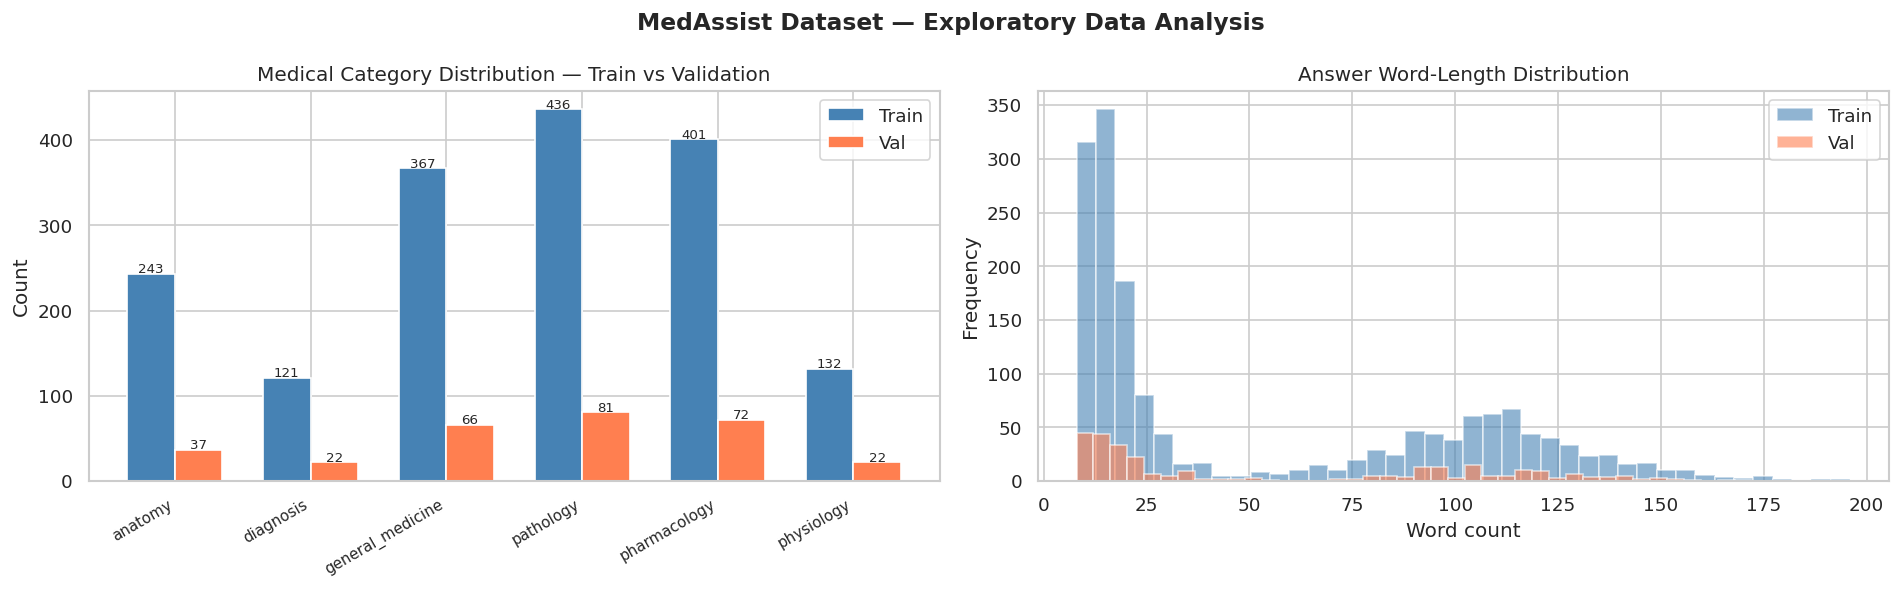

Train answer — mean: 54 words | median: 23 | max: 196
Val   answer — mean: 57 words | median: 28 | max: 172


In [6]:
# EDA: Category Distribution + Answer Length Distribution
# Add this guard at the top of the EDA cell
assert len(train_data) > 0, "train_data is empty — re-run the sampling cell"
assert len(val_data)   > 0, "val_data is empty — re-run the sampling cell"




train_cats = Counter(x["category"] for x in train_data)
val_cats   = Counter(x["category"] for x in val_data)

all_cats   = sorted(train_cats.keys())

x_pos = np.arange(len(all_cats))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("MedAssist Dataset — Exploratory Data Analysis", fontsize=14, fontweight="bold")

# Category bar chart
ax = axes[0]
bars1 = ax.bar(x_pos - width/2, [train_cats[c] for c in all_cats], width, label="Train", color="steelblue")
bars2 = ax.bar(x_pos + width/2, [val_cats.get(c, 0) for c in all_cats], width, label="Val", color="coral")
ax.set_xticks(x_pos)
ax.set_xticklabels(all_cats, rotation=30, ha="right", fontsize=9)
ax.set_title("Medical Category Distribution — Train vs Validation")
ax.set_ylabel("Count")
ax.legend()
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(b.get_height())), ha="center", fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(b.get_height())), ha="center", fontsize=8)

# Answer word-length histogram
ax2 = axes[1]
train_lens = [len(x["output"].split()) for x in train_data]
val_lens   = [len(x["output"].split()) for x in val_data]
ax2.hist(train_lens, bins=40, alpha=0.6, label="Train", color="steelblue")
ax2.hist(val_lens,   bins=40, alpha=0.6, label="Val",   color="coral")
ax2.set_title("Answer Word-Length Distribution")
ax2.set_xlabel("Word count")
ax2.set_ylabel("Frequency")
ax2.legend()

plt.tight_layout()
plt.savefig("eda_charts.png", bbox_inches="tight")
plt.show()
print(f"Train answer — mean: {np.mean(train_lens):.0f} words | median: {np.median(train_lens):.0f} | max: {max(train_lens)}")
print(f"Val   answer — mean: {np.mean(val_lens):.0f} words | median: {np.median(val_lens):.0f} | max: {max(val_lens)}")

## 2) Prompt Template & Preprocessing

In [7]:
# ✅ Qwen2.5 chat-template format for medical domain

SYSTEM_PROMPT = (
    "You are MedAssist, a domain-specific medical education assistant. "
    "Provide accurate, concise, and evidence-based answers to medical questions "
    "covering pharmacology, pathology, anatomy, physiology, and clinical diagnosis. "
    "If a question falls outside the medical domain, politely say so. "
    "Always remind users that your answers are for educational purposes only "
    "and that they should consult a qualified healthcare professional for clinical decisions."
)

def build_prompt(example: dict) -> str:
    """Build the instruction-only prompt (used for inference and label masking)."""
    instr    = example["instruction"].strip()
    inp      = (example.get("input", "") or "").strip()
    user_msg = f"{instr}\n\nContext:\n{inp}" if inp else instr
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

def build_full_text(example: dict) -> str:
    """Full text = prompt + answer (used for training)."""
    return build_prompt(example) + example["output"].strip() + "<|im_end|>"

# Build HuggingFace Datasets
train_ds = Dataset.from_list(train_data).map(
    lambda x: {"text": build_full_text(x), "prompt": build_prompt(x)},
    remove_columns=Dataset.from_list(train_data).column_names
)
val_ds = Dataset.from_list(val_data).map(
    lambda x: {"text": build_full_text(x), "prompt": build_prompt(x)},
    remove_columns=Dataset.from_list(val_data).column_names
)

print("Train dataset:", train_ds)
print("Val   dataset:", val_ds)
print("\n--- Example formatted prompt (first 700 chars) ---")
print(train_ds[0]["text"][:700])

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Train dataset: Dataset({
    features: ['text', 'prompt'],
    num_rows: 1700
})
Val   dataset: Dataset({
    features: ['text', 'prompt'],
    num_rows: 300
})

--- Example formatted prompt (first 700 chars) ---
<|im_start|>system
You are MedAssist, a domain-specific medical education assistant. Provide accurate, concise, and evidence-based answers to medical questions covering pharmacology, pathology, anatomy, physiology, and clinical diagnosis. If a question falls outside the medical domain, politely say so. Always remind users that your answers are for educational purposes only and that they should consult a qualified healthcare professional for clinical decisions.<|im_end|>
<|im_start|>user
Answer this question truthfully<|im_end|>
<|im_start|>assistant
Hyposmotic volume expansion typically does not cause any significant change in hematocrit levels.<|im_end|>


## 3) Tokenizer Loading + Tokenization with Label Masking

In [8]:
# ✅ Load Qwen2.5 tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"   # Required for causal LM training

# MAX_LEN=256 — medical flashcard answers are short (avg ~30 words / ~40 tokens)
# This fits safely on a T4 GPU with bs=1
MAX_LEN = 256

def tokenize_with_label_mask(example):
    """
    Tokenize full text (prompt + answer).
    Mask ALL prompt tokens with -100 so training loss is computed
    ONLY on the answer tokens — standard instruction-tuning approach.
    """
    full_enc   = tokenizer(example["text"],   truncation=True, max_length=MAX_LEN, padding="max_length")
    prompt_enc = tokenizer(example["prompt"], truncation=True, max_length=MAX_LEN, padding=False)

    prompt_len = len(prompt_enc["input_ids"])
    input_ids  = full_enc["input_ids"]
    labels     = [-100] * prompt_len + input_ids[prompt_len:]   # Mask prompt tokens

    pad_count = MAX_LEN - len(labels)
    if pad_count > 0:
        labels = labels + [-100] * pad_count
    labels = labels[:MAX_LEN]

    return {
        "input_ids":      [int(x) for x in input_ids],
        "attention_mask": [int(x) for x in full_enc["attention_mask"]],
        "labels":         [int(x) for x in labels],
    }

print("Tokenizing train set...")
train_tok = train_ds.map(tokenize_with_label_mask, batched=False, remove_columns=["text", "prompt"])
print("Tokenizing validation set...")
val_tok   = val_ds.map(tokenize_with_label_mask, batched=False, remove_columns=["text", "prompt"])

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch",   columns=["input_ids", "attention_mask", "labels"])

sample_labels = train_tok[0]["labels"]
non_masked = (sample_labels != -100).sum().item()
print(f"\n✅ Tokenization done.")
print(f"   MAX_LEN                       : {MAX_LEN}")
print(f"   Train examples                : {len(train_tok):,}")
print(f"   Val   examples                : {len(val_tok):,}")
print(f"   Answer tokens (sample, unmasked): {non_masked} / {MAX_LEN}")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train set...


Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Tokenizing validation set...


Map:   0%|          | 0/300 [00:00<?, ? examples/s]


✅ Tokenization done.
   MAX_LEN                       : 256
   Train examples                : 1,700
   Val   examples                : 300
   Answer tokens (sample, unmasked): 162 / 256


## 4) Shared Metrics & Utility Functions

In [9]:
# ✅ Load HuggingFace evaluators
rouge_metric = evaluate.load("rouge")
bleu_metric  = evaluate.load("sacrebleu")

# ── Text normalization ──────────────────────────────────────────────
def normalize(s: str) -> str:
    s = (s or "").lower().strip()
    s = re.sub(r"\s+",     " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s

# ── Exact Match ─────────────────────────────────────────────────────
def exact_match(pred: str, ref: str) -> float:
    return float(normalize(pred) == normalize(ref))

# ── Token-level F1 ──────────────────────────────────────────────────
def token_f1(pred: str, ref: str) -> float:
    p_toks = normalize(pred).split()
    r_toks = normalize(ref).split()
    if not p_toks and not r_toks: return 1.0
    if not p_toks or  not r_toks: return 0.0
    common   = Counter(p_toks) & Counter(r_toks)
    n_common = sum(common.values())
    if n_common == 0: return 0.0
    precision = n_common / len(p_toks)
    recall    = n_common / len(r_toks)
    return 2 * precision * recall / (precision + recall)

# ── Medical Keyphrase accuracy per category ──────────────────────────
# Each category has domain-specific clinical keywords.
# A prediction scores positively if it contains >= MIN_KP_HITS keywords.
KEYPHRASES = {
    "pharmacology":   ["drug", "dose", "receptor", "inhibit", "toxicity", "mechanism", "administr"],
    "pathology":      ["infect", "inflam", "lesion", "necrosis", "tumor", "bacteria", "virus"],
    "anatomy":        ["muscle", "nerve", "artery", "vein", "organ", "bone", "structure"],
    "physiology":     ["hormone", "enzyme", "metabol", "function", "blood", "heart", "respir"],
    "diagnosis":      ["symptom", "sign", "test", "diagnos", "imaging", "lab", "examination"],
    "general_medicine": ["treatment", "patient", "clinical", "medical", "health", "condition"],
}
MIN_KP_HITS = 2

def keyphrase_accuracy(preds, cats):
    grouped = defaultdict(list)
    for pred, cat in zip(preds, cats):
        grouped[cat].append(pred.lower())
    results = {}
    for cat, texts in grouped.items():
        phrases = KEYPHRASES.get(cat, [])
        if not phrases: continue
        correct = sum(
            1 for t in texts
            if sum(1 for p in phrases if p in t) >= MIN_KP_HITS
        )
        results[cat] = correct / len(texts)
    overall = (
        sum(v * len(grouped[c]) for c, v in results.items()) /
        sum(len(grouped[c]) for c in results)
    ) if results else 0.0
    return overall, results

# ── Master metrics function ──────────────────────────────────────────
def compute_metrics(preds, refs, cats, eval_loss=None):
    bleu   = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])["score"]
    rouge  = rouge_metric.compute(predictions=preds, references=refs)
    ppl    = math.exp(eval_loss) if eval_loss is not None else None
    em     = np.mean([exact_match(p, r) for p, r in zip(preds, refs)])
    f1     = np.mean([token_f1(p, r)    for p, r in zip(preds, refs)])
    kp_acc, kp_by_cat = keyphrase_accuracy(preds, cats)

    out = {
        "BLEU":         round(float(bleu),             4),
        "ROUGE-1":      round(float(rouge["rouge1"]),  4),
        "ROUGE-2":      round(float(rouge["rouge2"]),  4),
        "ROUGE-L":      round(float(rouge["rougeL"]),  4),
        "Perplexity":   round(float(ppl),              4) if ppl else None,
        "ExactMatch":   round(float(em),               4),
        "TokenF1":      round(float(f1),               4),
        "KeyphraseAcc": round(float(kp_acc),           4),
    }
    for cat, acc in kp_by_cat.items():
        out[f"KP_{cat}"] = round(float(acc), 4)
    return out

# ── Batched inference (4 samples per batch — much faster than sequential) ──
def generate_predictions(model, n_samples=40, max_new_tokens=80):
    idxs    = random.sample(range(len(val_ds)), k=min(n_samples, len(val_ds)))
    prompts = [val_ds[i]["prompt"] for i in idxs]
    refs    = [val_data[i]["output"].strip()                  for i in idxs]
    cats    = [val_data[i].get("category", "unknown").strip() for i in idxs]

    preds = []
    model.eval()
    tokenizer.padding_side = "left"   # Required for batched generation
    BATCH = 4

    for i in range(0, len(prompts), BATCH):
        batch_prompts = prompts[i : i + BATCH]
        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
        ).to(model.device)
        with torch.no_grad():
            outs = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=1,
                pad_token_id=tokenizer.eos_token_id,
            )
        for j in range(len(batch_prompts)):
            input_len  = enc["input_ids"][j].shape[0]
            answer_ids = outs[j][input_len:]
            answer     = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
            preds.append(answer)

    tokenizer.padding_side = "right"  # Reset for training
    return preds, refs, cats

# ── Single-query inference (for Gradio UI and qualitative testing) ───
def chat(model, question: str, context: str = "", max_new_tokens=150) -> str:
    ex     = {"instruction": question, "input": context, "output": ""}
    prompt = build_prompt(ex)
    enc    = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded_full   = tokenizer.decode(out[0], skip_special_tokens=True)
    decoded_prompt = tokenizer.decode(enc["input_ids"][0], skip_special_tokens=True)
    return (
        decoded_full[len(decoded_prompt):].strip()
        if decoded_full.startswith(decoded_prompt)
        else decoded_full.strip()
    )

# ── Free GPU memory between experiments ─────────────────────────────
def free_gpu(model=None):
    if model is not None:
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    free_mem = torch.cuda.mem_get_info()[0] / 1e9 if torch.cuda.is_available() else 0
    print(f"🧹 GPU cleared. Free: {free_mem:.2f} GB")

# ── Shared 4-bit quantization config ────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
)

# ── Results store ─────────────────────────────────────────────────────
ALL_RESULTS   = []
ALL_HISTORIES = {}

print("✅ Metrics, inference helpers, and utilities loaded.")

✅ Metrics, inference helpers, and utilities loaded.


---
## 5) Experiment 1 — Conservative Baseline
**LoRA r=8 | LR=2e-4 | 1 epoch | Batch 1 × grad_accum 16**  
Fastest configuration. Low rank = fewer trainable parameters. High LR explores aggressively in one pass.


In [10]:
# ════════════════════════════════════════════════════════════════
#  EXPERIMENT 1 — Conservative Baseline
#  r=8 | lora_alpha=16 | lr=2e-4 | epochs=1 | bs=1 | grad_accum=16
# ════════════════════════════════════════════════════════════════
EXP1_NAME = "Exp1_r8_lr2e4_1ep"
EXP1_CFG  = dict(r=8, lora_alpha=16, lr=2e-4, epochs=1, bs=1, grad_accum=16)

print(f"{'='*70}")
print(f"  {EXP1_NAME}")
print(f"  Config: {EXP1_CFG}")
print(f"{'='*70}")

if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

# 1. Load base model with 4-bit quantization
model_exp1 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
)
model_exp1 = prepare_model_for_kbit_training(model_exp1, use_gradient_checkpointing=False)

# 2. Apply LoRA adapter
lora_exp1 = LoraConfig(
    r=EXP1_CFG["r"],
    lora_alpha=EXP1_CFG["lora_alpha"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
model_exp1 = get_peft_model(model_exp1, lora_exp1)
model_exp1.print_trainable_parameters()

# 3. Training arguments
args_exp1 = TrainingArguments(
    output_dir=f"./runs/{EXP1_NAME}",
    learning_rate=EXP1_CFG["lr"],
    per_device_train_batch_size=EXP1_CFG["bs"],
    per_device_eval_batch_size=EXP1_CFG["bs"],
    gradient_accumulation_steps=EXP1_CFG["grad_accum"],
    num_train_epochs=EXP1_CFG["epochs"],
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=30,
    fp16=not torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    optim="paged_adamw_8bit",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    max_grad_norm=1.0,
    warmup_steps=50,
    dataloader_pin_memory=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=SEED,
)

# 4. Train
trainer_exp1 = Trainer(
    model=model_exp1, args=args_exp1,
    train_dataset=train_tok, eval_dataset=val_tok,
    data_collator=DefaultDataCollator(),
)
t0 = time.time()
trainer_exp1.train()
exp1_time = time.time() - t0

# 5. Evaluate
eval_out_exp1  = trainer_exp1.evaluate()
eval_loss_exp1 = float(eval_out_exp1["eval_loss"])
print(f"\nEval Loss: {eval_loss_exp1:.4f} | Perplexity: {math.exp(eval_loss_exp1):.2f}")

# 6. Predictions + full metrics
preds_exp1, refs_exp1, cats_exp1 = generate_predictions(model_exp1, n_samples=40, max_new_tokens=80)
metrics_exp1 = compute_metrics(preds_exp1, refs_exp1, cats_exp1, eval_loss=eval_loss_exp1)

# 7. Training history
ALL_HISTORIES[EXP1_NAME] = [
    (e["epoch"], e.get("loss"), e.get("eval_loss"))
    for e in trainer_exp1.state.log_history if "eval_loss" in e or "loss" in e
]

# 8. Record results
gpu_mem_exp1 = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else None
row_exp1 = {
    "Experiment": EXP1_NAME, "LoRA_r": EXP1_CFG["r"], "LR": EXP1_CFG["lr"],
    "Epochs": EXP1_CFG["epochs"], "BatchSize": EXP1_CFG["bs"],
    "GradAccum": EXP1_CFG["grad_accum"], "EvalLoss": round(eval_loss_exp1, 4),
    "TrainTime_min": round(exp1_time/60, 1),
    "GPU_mem_GB": round(gpu_mem_exp1, 2) if gpu_mem_exp1 else None,
    **metrics_exp1,
}
ALL_RESULTS.append(row_exp1)

# 9. Save adapter
os.makedirs(f"./adapters/{EXP1_NAME}", exist_ok=True)
model_exp1.save_pretrained(f"./adapters/{EXP1_NAME}")
tokenizer.save_pretrained(f"./adapters/{EXP1_NAME}")

print(f"\n✅ Experiment 1 done in {exp1_time/60:.1f} min")
print(f"   BLEU={metrics_exp1['BLEU']:.4f} | ROUGE-L={metrics_exp1['ROUGE-L']:.4f} | F1={metrics_exp1['TokenF1']:.4f} | PPL={metrics_exp1['Perplexity']}")

free_gpu(model_exp1)

  Exp1_r8_lr2e4_1ep
  Config: {'r': 8, 'lora_alpha': 16, 'lr': 0.0002, 'epochs': 1, 'bs': 1, 'grad_accum': 16}


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


Epoch,Training Loss,Validation Loss
1,0.580543,0.630187


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Eval Loss: 0.6302 | Perplexity: 1.88

✅ Experiment 1 done in 46.6 min
   BLEU=0.3883 | ROUGE-L=0.0891 | F1=0.1222 | PPL=1.878
🧹 GPU cleared. Free: 13.70 GB


---
## 6) Experiment 2 — Balanced Configuration
**LoRA r=16 | LR=1e-4 | 2 epochs | Batch 1 × grad_accum 16**  
Doubles the rank, halves the LR, trains for 2 epochs to allow better convergence.


In [11]:
# ════════════════════════════════════════════════════════════════
#  EXPERIMENT 2 — Balanced Configuration
#  r=16 | lora_alpha=32 | lr=1e-4 | epochs=2 | bs=1 | grad_accum=16
# ════════════════════════════════════════════════════════════════
EXP2_NAME = "Exp2_r16_lr1e4_2ep"
EXP2_CFG  = dict(r=16, lora_alpha=32, lr=1e-4, epochs=2, bs=1, grad_accum=16)

print(f"{'='*70}")
print(f"  {EXP2_NAME}")
print(f"  Config: {EXP2_CFG}")
print(f"{'='*70}")

if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

model_exp2 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True,
    low_cpu_mem_usage=True, torch_dtype=torch.float16,
)
model_exp2 = prepare_model_for_kbit_training(model_exp2, use_gradient_checkpointing=False)

lora_exp2 = LoraConfig(
    r=EXP2_CFG["r"], lora_alpha=EXP2_CFG["lora_alpha"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
model_exp2 = get_peft_model(model_exp2, lora_exp2)
model_exp2.print_trainable_parameters()

args_exp2 = TrainingArguments(
    output_dir=f"./runs/{EXP2_NAME}",
    learning_rate=EXP2_CFG["lr"],
    per_device_train_batch_size=EXP2_CFG["bs"],
    per_device_eval_batch_size=EXP2_CFG["bs"],
    gradient_accumulation_steps=EXP2_CFG["grad_accum"],
    num_train_epochs=EXP2_CFG["epochs"],
    eval_strategy="epoch", save_strategy="epoch",
    logging_steps=30,
    fp16=not torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    optim="paged_adamw_8bit", report_to="none",
    load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
    max_grad_norm=1.0, warmup_steps=50, dataloader_pin_memory=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=SEED,
)

trainer_exp2 = Trainer(
    model=model_exp2, args=args_exp2,
    train_dataset=train_tok, eval_dataset=val_tok,
    data_collator=DefaultDataCollator(),
)
t0 = time.time()
trainer_exp2.train()
exp2_time = time.time() - t0

eval_out_exp2  = trainer_exp2.evaluate()
eval_loss_exp2 = float(eval_out_exp2["eval_loss"])
print(f"\nEval Loss: {eval_loss_exp2:.4f} | Perplexity: {math.exp(eval_loss_exp2):.2f}")

preds_exp2, refs_exp2, cats_exp2 = generate_predictions(model_exp2, n_samples=40, max_new_tokens=80)
metrics_exp2 = compute_metrics(preds_exp2, refs_exp2, cats_exp2, eval_loss=eval_loss_exp2)

ALL_HISTORIES[EXP2_NAME] = [
    (e["epoch"], e.get("loss"), e.get("eval_loss"))
    for e in trainer_exp2.state.log_history if "eval_loss" in e or "loss" in e
]

gpu_mem_exp2 = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else None
row_exp2 = {
    "Experiment": EXP2_NAME, "LoRA_r": EXP2_CFG["r"], "LR": EXP2_CFG["lr"],
    "Epochs": EXP2_CFG["epochs"], "BatchSize": EXP2_CFG["bs"],
    "GradAccum": EXP2_CFG["grad_accum"], "EvalLoss": round(eval_loss_exp2, 4),
    "TrainTime_min": round(exp2_time/60, 1),
    "GPU_mem_GB": round(gpu_mem_exp2, 2) if gpu_mem_exp2 else None,
    **metrics_exp2,
}
ALL_RESULTS.append(row_exp2)

os.makedirs(f"./adapters/{EXP2_NAME}", exist_ok=True)
model_exp2.save_pretrained(f"./adapters/{EXP2_NAME}")
tokenizer.save_pretrained(f"./adapters/{EXP2_NAME}")

print(f"\n✅ Experiment 2 done in {exp2_time/60:.1f} min")
print(f"   BLEU={metrics_exp2['BLEU']:.4f} | ROUGE-L={metrics_exp2['ROUGE-L']:.4f} | F1={metrics_exp2['TokenF1']:.4f} | PPL={metrics_exp2['Perplexity']}")

free_gpu(model_exp2)

  Exp2_r16_lr1e4_2ep
  Config: {'r': 16, 'lora_alpha': 32, 'lr': 0.0001, 'epochs': 2, 'bs': 1, 'grad_accum': 16}


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Epoch,Training Loss,Validation Loss
1,0.580688,0.624607
2,0.567348,0.613690



Eval Loss: 0.6137 | Perplexity: 1.85

✅ Experiment 2 done in 94.1 min
   BLEU=0.0317 | ROUGE-L=0.1031 | F1=0.1178 | PPL=1.8472
🧹 GPU cleared. Free: 11.84 GB


---
## 8) Experiment 4 — High Rank + Aggressive LR
**LoRA r=64 | LR=2e-4 | 2 epochs | Batch 1 × grad_accum 16**  
Maximum expressiveness. Tests if very high rank with fast LR converges better or overfits.


In [13]:
# ════════════════════════════════════════════════════════════════
#  EXPERIMENT 4 — High Rank + Aggressive LR
#  r=64 | lora_alpha=128 | lr=2e-4 | epochs=1 | bs=1 | grad_accum=16
# ════════════════════════════════════════════════════════════════
EXP4_NAME = "Exp4_r64_lr2e4_2ep"
EXP4_CFG  = dict(r=64, lora_alpha=128, lr=2e-4, epochs=1, bs=1, grad_accum=16)

print(f"{'='*70}")
print(f"  {EXP4_NAME}")
print(f"  Config: {EXP4_CFG}")
print(f"{'='*70}")

if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

model_exp4 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True,
    low_cpu_mem_usage=True, torch_dtype=torch.float16,
)
model_exp4 = prepare_model_for_kbit_training(model_exp4, use_gradient_checkpointing=False)

lora_exp4 = LoraConfig(
    r=EXP4_CFG["r"], lora_alpha=EXP4_CFG["lora_alpha"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
model_exp4 = get_peft_model(model_exp4, lora_exp4)
model_exp4.print_trainable_parameters()

args_exp4 = TrainingArguments(
    output_dir=f"./runs/{EXP4_NAME}",
    learning_rate=EXP4_CFG["lr"],
    per_device_train_batch_size=EXP4_CFG["bs"],
    per_device_eval_batch_size=EXP4_CFG["bs"],
    gradient_accumulation_steps=EXP4_CFG["grad_accum"],
    num_train_epochs=EXP4_CFG["epochs"],
    eval_strategy="epoch", save_strategy="epoch",
    logging_steps=30,
    fp16=not torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    optim="paged_adamw_8bit", report_to="none",
    load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
    max_grad_norm=1.0, warmup_steps=50, dataloader_pin_memory=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=SEED,
)

trainer_exp4 = Trainer(
    model=model_exp4, args=args_exp4,
    train_dataset=train_tok, eval_dataset=val_tok,
    data_collator=DefaultDataCollator(),
)
t0 = time.time()
trainer_exp4.train()
exp4_time = time.time() - t0

eval_out_exp4  = trainer_exp4.evaluate()
eval_loss_exp4 = float(eval_out_exp4["eval_loss"])
print(f"\nEval Loss: {eval_loss_exp4:.4f} | Perplexity: {math.exp(eval_loss_exp4):.2f}")

preds_exp4, refs_exp4, cats_exp4 = generate_predictions(model_exp4, n_samples=40, max_new_tokens=80)
metrics_exp4 = compute_metrics(preds_exp4, refs_exp4, cats_exp4, eval_loss=eval_loss_exp4)

ALL_HISTORIES[EXP4_NAME] = [
    (e["epoch"], e.get("loss"), e.get("eval_loss"))
    for e in trainer_exp4.state.log_history if "eval_loss" in e or "loss" in e
]

gpu_mem_exp4 = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else None
row_exp4 = {
    "Experiment": EXP4_NAME, "LoRA_r": EXP4_CFG["r"], "LR": EXP4_CFG["lr"],
    "Epochs": EXP4_CFG["epochs"], "BatchSize": EXP4_CFG["bs"],
    "GradAccum": EXP4_CFG["grad_accum"], "EvalLoss": round(eval_loss_exp4, 4),
    "TrainTime_min": round(exp4_time/60, 1),
    "GPU_mem_GB": round(gpu_mem_exp4, 2) if gpu_mem_exp4 else None,
    **metrics_exp4,
}
ALL_RESULTS.append(row_exp4)

os.makedirs(f"./adapters/{EXP4_NAME}", exist_ok=True)
model_exp4.save_pretrained(f"./adapters/{EXP4_NAME}")
tokenizer.save_pretrained(f"./adapters/{EXP4_NAME}")

print(f"\n✅ Experiment 4 done in {exp4_time/60:.1f} min")
print(f"   BLEU={metrics_exp4['BLEU']:.4f} | ROUGE-L={metrics_exp4['ROUGE-L']:.4f} | F1={metrics_exp4['TokenF1']:.4f} | PPL={metrics_exp4['Perplexity']}")

free_gpu(model_exp4)

  Exp4_r64_lr2e4_2ep
  Config: {'r': 64, 'lora_alpha': 128, 'lr': 0.0002, 'epochs': 1, 'bs': 1, 'grad_accum': 16}


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 73,859,072 || all params: 1,617,573,376 || trainable%: 4.5660


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.549834,0.598610



Eval Loss: 0.5986 | Perplexity: 1.82

✅ Experiment 4 done in 48.3 min
   BLEU=0.8466 | ROUGE-L=0.0994 | F1=0.1344 | PPL=1.8196
🧹 GPU cleared. Free: 7.52 GB


## 9) Cross-Experiment Comparison — Tables & Graphs

In [15]:
# ✅ 9a) Master results table
df = pd.DataFrame(ALL_RESULTS)
display_cols = ["Experiment", "LoRA_r", "LR", "Epochs", "EvalLoss",
                "Perplexity", "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L",
                "TokenF1", "ExactMatch", "KeyphraseAcc",
                "TrainTime_min", "GPU_mem_GB"]
display_cols = [c for c in display_cols if c in df.columns]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\n" + "="*90)
print("  MedAssist — EXPERIMENT RESULTS TABLE")
print("="*90)
print(df[display_cols].to_string(index=False))

best_idx  = df["EvalLoss"].idxmin()
best_name = df.loc[best_idx, "Experiment"]
print(f"\n🏆 Best experiment: {best_name} (EvalLoss={df.loc[best_idx,'EvalLoss']})")


  MedAssist — EXPERIMENT RESULTS TABLE
        Experiment  LoRA_r     LR  Epochs  EvalLoss  Perplexity   BLEU  ROUGE-1  ROUGE-2  ROUGE-L  TokenF1  ExactMatch  KeyphraseAcc  TrainTime_min  GPU_mem_GB
 Exp1_r8_lr2e4_1ep       8 0.0002       1    0.6302      1.8780 0.3883   0.1201   0.0081   0.0891   0.1222         0.0         0.275           46.6        2.70
Exp2_r16_lr1e4_2ep      16 0.0001       2    0.6137      1.8472 0.0317   0.1152   0.0020   0.1031   0.1178         0.0         0.000           94.1        4.44
Exp4_r64_lr2e4_2ep      64 0.0002       1    0.5986      1.8196 0.8466   0.1328   0.0068   0.0994   0.1344         0.0         0.000           48.3        8.95

🏆 Best experiment: Exp4_r64_lr2e4_2ep (EvalLoss=0.5986)


In [ ]:
# ✅ 9b) Styled HTML table — green highlights best per column
lower_better  = ["EvalLoss", "Perplexity", "TrainTime_min"]
higher_better = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "TokenF1", "ExactMatch", "KeyphraseAcc"]

styled = df[display_cols].set_index("Experiment").style
for c in lower_better:
    if c in df.columns: styled = styled.highlight_min(subset=[c], color="#c6efce")
for c in higher_better:
    if c in df.columns: styled = styled.highlight_max(subset=[c], color="#c6efce")
styled

In [ ]:
# ✅ 9c) Bar charts — 6 key metrics across experiments
exp_names   = df["Experiment"].tolist()
short_names = [e.split("_")[0] for e in exp_names]
colors      = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

metrics_to_plot = [
    ("EvalLoss",     "Evaluation Loss",   True,  "Loss"),
    ("Perplexity",   "Perplexity",        True,  "PPL"),
    ("BLEU",         "BLEU Score",        False, "BLEU"),
    ("ROUGE-L",      "ROUGE-L",           False, "Score"),
    ("TokenF1",      "Token-level F1",    False, "F1"),
    ("KeyphraseAcc", "Keyphrase Accuracy",False, "Accuracy"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("MedAssist — Experiment Comparison (Qwen2.5-1.5B + LoRA)",
             fontsize=14, fontweight="bold", y=1.01)

for ax, (col, title, lower_is_better, ylabel) in zip(axes.flat, metrics_to_plot):
    vals = df[col].tolist()
    bars = ax.bar(short_names, vals, color=colors[:len(vals)], edgecolor="white", linewidth=0.8)
    best_val = min(vals) if lower_is_better else max(vals)
    for bar, val in zip(bars, vals):
        if val == best_val: bar.set_facecolor("#2ca02c")
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=20, ha="right", fontsize=9)
    ax.set_xlabel("▼ lower=better" if lower_is_better else "▲ higher=better", fontsize=8, color="gray")

best_patch = mpatches.Patch(color="#2ca02c", label="Best value")
fig.legend(handles=[best_patch], loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("experiment_comparison_bars.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# ✅ 9d) Radar chart — multi-metric overview
radar_metrics = [m for m in ["BLEU", "ROUGE-1", "ROUGE-L", "TokenF1", "KeyphraseAcc"] if m in df.columns]
N      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in df.iterrows():
    vals = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    ax.plot(angles, vals, "o-", linewidth=2, label=short_names[i], color=colors[i % len(colors)])
    ax.fill(angles, vals, alpha=0.08, color=colors[i % len(colors)])
ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_title("MedAssist — Radar Metric Comparison\n(all axes: higher = better)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig("radar_chart.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# ✅ 9e) Training & Eval loss curves per experiment
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training & Evaluation Loss Curves — All Experiments", fontsize=14, fontweight="bold")

for ax, (name, history) in zip(axes.flat, ALL_HISTORIES.items()):
    train_pts = [(e, l) for e, l, _ in history if l is not None]
    eval_pts  = [(e, l) for e, _, l in history if l is not None]
    if train_pts:
        tx, ty = zip(*train_pts)
        ax.plot(tx, ty, "o-", label="Train Loss", color="steelblue", linewidth=2)
    if eval_pts:
        ex, ey = zip(*eval_pts)
        ax.plot(ex, ey, "s--", label="Val Loss",   color="coral",     linewidth=2)
    ax.set_title(name.replace("_", " "), fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# ✅ 9f) Keyphrase accuracy by medical category — grouped bar chart
kp_cols   = [c for c in df.columns if c.startswith("KP_")]
cat_names = [c.replace("KP_", "") for c in kp_cols]

if kp_cols:
    x = np.arange(len(cat_names))
    w = 0.2
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (_, row) in enumerate(df.iterrows()):
        vals = [row.get(c, 0) for c in kp_cols]
        ax.bar(x + i*w - w*1.5, vals, width=w, label=short_names[i],
               color=colors[i % len(colors)], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_names, rotation=25, ha="right", fontsize=10)
    ax.set_ylabel("Keyphrase Accuracy")
    ax.set_title("Medical Keyphrase Accuracy by Category — All Experiments", fontsize=12)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.savefig("keyphrase_by_category.png", bbox_inches="tight", dpi=150)
    plt.show()

In [ ]:
# ✅ 9g) Metric heatmap
heatmap_cols = [c for c in ["BLEU","ROUGE-1","ROUGE-2","ROUGE-L","TokenF1","ExactMatch","KeyphraseAcc"] if c in df.columns]
hm_df = df.set_index("Experiment")[heatmap_cols].astype(float)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(hm_df, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Score"})
ax.set_title("Metric Heatmap — MedAssist Experiments vs Scores", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("metric_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# ✅ 9h) Training efficiency scatter: time vs Token-F1
fig, ax = plt.subplots(figsize=(9, 6))
for i, row in df.iterrows():
    ax.scatter(row["TrainTime_min"], row["TokenF1"],
               s=200, color=colors[i % len(colors)],
               label=short_names[i], zorder=5, edgecolors="black", linewidth=0.8)
    ax.annotate(short_names[i], (row["TrainTime_min"], row["TokenF1"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Training Time (minutes)", fontsize=11)
ax.set_ylabel("Token-F1 Score",          fontsize=11)
ax.set_title("Training Efficiency: Time vs Token-F1", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("efficiency_scatter.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n✅ All comparison charts saved.")

---
## 9i) Save Best Model for Gradio Deployment
Copy the best-performing LoRA adapter to a dedicated `./medassist_best_model/` directory and write a `model_metadata.json` file. The Gradio app in Section 11 reads this directory to load the model without re-running experiments.

In [16]:
import json, shutil

# ════════════════════════════════════════════════════════════════
#  SAVE BEST PERFORMING MODEL for Gradio web app inference
#  ▸ Copies the best adapter weights to a dedicated directory
#  ▸ Writes model_metadata.json so the Gradio app can reload it
#    without re-running all experiments
# ════════════════════════════════════════════════════════════════
BEST_MODEL_DIR = "./medassist_best_model"

print("=" * 70)
print(f"  💾 Saving best model to : {BEST_MODEL_DIR}")
print(f"  🏆 Best experiment      : {best_name}")
print(f"  📊 Eval Loss            : {df.loc[best_idx, 'EvalLoss']}")
print("=" * 70)

# 1. Copy adapter weights from the best experiment save directory
src_path = f"./adapters/{best_name}"
if os.path.exists(src_path):
    if os.path.exists(BEST_MODEL_DIR):
        shutil.rmtree(BEST_MODEL_DIR)
    shutil.copytree(src_path, BEST_MODEL_DIR)
    print(f"\n✅ Adapter weights copied: {src_path} → {BEST_MODEL_DIR}")
else:
    print(f"\n⚠️  Adapter source not found at {src_path}.")
    print("    Ensure all experiment cells ran and saved their adapters.")

# 2. Persist key metadata so the Gradio app can self-configure
best_row = df[df["Experiment"] == best_name].iloc[0].to_dict()
model_metadata = {
    "base_model":      MODEL_NAME,
    "best_experiment": best_name,
    "adapter_path":    BEST_MODEL_DIR,
    "lora_r":          int(best_row.get("LoRA_r", 0)),
    "learning_rate":   best_row.get("LR"),
    "epochs":          int(best_row.get("Epochs", 0)),
    "eval_loss":       best_row.get("EvalLoss"),
    "perplexity":      best_row.get("Perplexity"),
    "bleu":            best_row.get("BLEU"),
    "rouge_l":         best_row.get("ROUGE-L"),
    "token_f1":        best_row.get("TokenF1"),
    "system_prompt":   SYSTEM_PROMPT,
    "max_len":         MAX_LEN,
}

metadata_path = os.path.join(BEST_MODEL_DIR, "model_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=2)
print(f"✅ Metadata saved        : {metadata_path}")

# 3. Verify all critical files are present
EXPECTED = {"adapter_config.json", "adapter_model.safetensors",
            "tokenizer.json", "tokenizer_config.json", "model_metadata.json"}
print("\nFiles saved in best-model directory:")
for fname in sorted(os.listdir(BEST_MODEL_DIR)):
    size_kb = os.path.getsize(os.path.join(BEST_MODEL_DIR, fname)) / 1024
    tag = "✅" if fname in EXPECTED else "  "
    print(f"  {tag}  {fname:<48} ({size_kb:>10,.1f} KB)")

missing = EXPECTED - set(os.listdir(BEST_MODEL_DIR))
if missing:
    print(f"\n⚠️  Missing expected files: {missing}")
else:
    print("\n✨ All critical files present — model is ready for Gradio.")

# 4. Print the exact snippet the Gradio cell should use to reload the model
print(f"""
--- HOW TO LOAD THIS MODEL IN THE GRADIO APP (Section 11) ---

    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    from peft import PeftModel
    import torch, json

    BEST_MODEL_DIR = "{BEST_MODEL_DIR}"
    with open(f"{{BEST_MODEL_DIR}}/model_metadata.json") as f:
        meta = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR, trust_remote_code=True)
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.padding_side = "left"

    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        meta["base_model"],
        quantization_config=bnb_cfg,
        device_map="auto",
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    ft_model = PeftModel.from_pretrained(base_model, BEST_MODEL_DIR)
    ft_model.eval()
    print(f"Model loaded from {{BEST_MODEL_DIR}}")
--------------------------------------------------------------
""")


  💾 Saving best model to : ./medassist_best_model
  🏆 Best experiment      : Exp4_r64_lr2e4_2ep
  📊 Eval Loss            : 0.5986

✅ Adapter weights copied: ./adapters/Exp4_r64_lr2e4_2ep → ./medassist_best_model
✅ Metadata saved        : ./medassist_best_model/model_metadata.json

Files saved in best-model directory:
      README.md                                        (       5.1 KB)
  ✅  adapter_config.json                              (       1.0 KB)
  ✅  adapter_model.safetensors                        ( 288,563.4 KB)
      chat_template.jinja                              (       2.4 KB)
  ✅  model_metadata.json                              (       0.8 KB)
  ✅  tokenizer.json                                   (  11,154.4 KB)
  ✅  tokenizer_config.json                            (       0.6 KB)

✨ All critical files present — model is ready for Gradio.

--- HOW TO LOAD THIS MODEL IN THE GRADIO APP (Section 11) ---

    from transformers import AutoTokenizer, AutoModelForCausalLM, 

## 10) Base Model vs Best Fine-Tuned — Qualitative & Quantitative Comparison

In [ ]:
# ✅ Load base model (no LoRA) and best fine-tuned adapter
from peft import PeftModel

print("Loading base Qwen2.5 model (no fine-tuning)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True,
    low_cpu_mem_usage=True, torch_dtype=torch.float16,
)
base_model.eval()
print("✅ Base model loaded.")

best_adapter_path = f"./adapters/{best_name}"
print(f"\nLoading best fine-tuned adapter: {best_name}...")
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True,
    low_cpu_mem_usage=True, torch_dtype=torch.float16,
)
ft_model = PeftModel.from_pretrained(ft_model, best_adapter_path)
ft_model.eval()
print(f"✅ Fine-tuned model loaded from {best_adapter_path}.")

In [ ]:
# ✅ Qualitative comparison — IN-DOMAIN and OUT-OF-DOMAIN medical queries
TEST_PROMPTS = [
    # --- In-domain medical questions ---
    {
        "label": "[IN-DOMAIN] Pharmacology",
        "q":   "What is the mechanism of action of beta-blockers?",
        "ctx": ""
    },
    {
        "label": "[IN-DOMAIN] Pathology",
        "q":   "What are the classic symptoms of myocardial infarction?",
        "ctx": ""
    },
    {
        "label": "[IN-DOMAIN] Anatomy",
        "q":   "What structures pass through the carpal tunnel?",
        "ctx": ""
    },
    {
        "label": "[IN-DOMAIN] Physiology",
        "q":   "How does the renin-angiotensin-aldosterone system regulate blood pressure?",
        "ctx": ""
    },
    {
        "label": "[IN-DOMAIN] Diagnosis",
        "q":   "What lab findings are expected in a patient with iron deficiency anemia?",
        "ctx": ""
    },
    # --- Out-of-domain queries (model should decline gracefully) ---
    {
        "label": "[OUT-OF-DOMAIN] Agriculture",
        "q":   "How do I prevent Newcastle disease in my chickens?",
        "ctx": ""
    },
    {
        "label": "[OUT-OF-DOMAIN] Cooking",
        "q":   "Can you give me a recipe for beef stew?",
        "ctx": ""
    },
]

for item in TEST_PROMPTS:
    print("\n" + "="*80)
    print(f"  {item['label']}")
    print(f"  Q: {item['q']}")
    print()
    print("  ── BASE MODEL (no fine-tuning) ──")
    print(f"  {chat(base_model, item['q'], item['ctx'])[:600]}")
    print()
    print(f"  ── FINE-TUNED MedAssist ({best_name}) ──")
    print(f"  {chat(ft_model, item['q'], item['ctx'])[:600]}")

In [ ]:
# ✅ Quantitative: Base vs Fine-tuned on same 30 held-out samples
random.seed(SEED)
n_compare = 30

print("Generating base model predictions...")
preds_base, refs_base, cats_base = generate_predictions(base_model, n_samples=n_compare, max_new_tokens=80)
metrics_base = compute_metrics(preds_base, refs_base, cats_base)

print("Generating fine-tuned predictions...")
random.seed(SEED)   # Same samples
preds_ft, refs_ft, cats_ft = generate_predictions(ft_model, n_samples=n_compare, max_new_tokens=80)
metrics_ft = compute_metrics(preds_ft, refs_ft, cats_ft)

compare_df = pd.DataFrame([
    {"Model": "Base Qwen2.5 (no fine-tuning)", **metrics_base},
    {"Model": f"MedAssist Fine-tuned ({best_name})", **metrics_ft},
])

core_cols = [c for c in ["Model","BLEU","ROUGE-1","ROUGE-2","ROUGE-L","TokenF1","ExactMatch","KeyphraseAcc"] if c in compare_df.columns]
print("\n" + "="*80)
print("  BASE vs FINE-TUNED — Quantitative Comparison (MedAssist)")
print("="*80)
print(compare_df[core_cols].to_string(index=False))

print("\nImprovement from fine-tuning:")
for col in ["BLEU", "ROUGE-L", "TokenF1", "KeyphraseAcc"]:
    if col in compare_df.columns:
        base_v = float(compare_df.loc[0, col])
        ft_v   = float(compare_df.loc[1, col])
        delta  = ft_v - base_v
        pct    = (delta / base_v * 100) if base_v > 0 else float("inf")
        print(f"  {col:15s}: {base_v:.4f} → {ft_v:.4f}  |  Δ {delta:+.4f} ({pct:+.1f}%)")

In [ ]:
# ✅ Base vs Fine-tuned visual bar chart
plot_metrics = [m for m in ["BLEU","ROUGE-1","ROUGE-L","TokenF1","KeyphraseAcc"] if m in compare_df.columns]
x     = np.arange(len(plot_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2,
               [float(compare_df.loc[0, m]) for m in plot_metrics],
               width, label="Base Qwen2.5", color="#aec6cf", edgecolor="white")
bars2 = ax.bar(x + width/2,
               [float(compare_df.loc[1, m]) for m in plot_metrics],
               width, label=f"MedAssist Fine-tuned ({best_name})", color="#2196f3", edgecolor="white")

for b in list(bars1) + list(bars2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
            f"{b.get_height():.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("Base Qwen2.5 vs MedAssist Fine-Tuned — Key Metrics",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, max(float(compare_df[plot_metrics].max().max()) * 1.2, 0.1))
plt.tight_layout()
plt.savefig("base_vs_finetuned.png", bbox_inches="tight", dpi=150)
plt.show()

## 11) Gradio UI — MedAssist Interactive Deployment

In [24]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch, json

BEST_MODEL_DIR = "./medassist_best_model"

with open(f"{BEST_MODEL_DIR}/model_metadata.json") as f:
    meta = json.load(f)

print(f"Loading model from : {BEST_MODEL_DIR}")
print(f"Base model         : {meta['base_model']}")
print(f"Best experiment    : {meta['best_experiment']}")

tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "left"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    meta["base_model"],
    quantization_config=bnb_cfg,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)

ft_model = PeftModel.from_pretrained(base_model, BEST_MODEL_DIR)
ft_model.eval()

print(f"\n✅ ft_model ready — you can now run the Gradio cell.")

Loading model from : ./medassist_best_model
Base model         : Qwen/Qwen2.5-1.5B-Instruct
Best experiment    : Exp4_r64_lr2e4_2ep


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


✅ ft_model ready — you can now run the Gradio cell.


In [25]:
import gradio as gr
print(f"Gradio version: {gr.__version__}")  # helps debug future issues

MEDICAL_CATEGORIES = [
    "General Medicine",
    "Pharmacology & Drugs",
    "Pathology & Disease",
    "Anatomy & Structure",
    "Physiology & Function",
    "Diagnosis & Symptoms",
]

EXAMPLE_QUERIES = [
    ["What is the mechanism of action of metformin?",        "", "Pharmacology & Drugs"],
    ["What are the symptoms of type 2 diabetes?",            "", "Pathology & Disease"],
    ["Which cranial nerve controls facial expression?",      "", "Anatomy & Structure"],
    ["How does the kidney regulate sodium balance?",         "", "Physiology & Function"],
    ["What blood test confirms iron deficiency anemia?",     "", "Diagnosis & Symptoms"],
    ["What is the first-line treatment for hypertension?",   "", "Pharmacology & Drugs"],
]

DISCLAIMER = (
    "⚠️ **Educational use only.** MedAssist is a fine-tuned AI model trained on medical flashcards. "
    "It is **not** a substitute for professional medical advice, diagnosis, or treatment. "
    "Always consult a qualified healthcare professional."
)

def respond(question, context, category, history):
    if not question.strip():
        return history, ""
    try:
        answer = chat(ft_model, question.strip(), (context or "").strip())
        answer += "\n\n*[Educational purposes only — consult a healthcare professional for medical decisions.]*"
    except Exception as e:
        answer = f"⚠️ Error: {e}"
    history.append({"role": "user",      "content": question})
    history.append({"role": "assistant", "content": answer})
    return history, ""

def clear_chat():
    return [], "", ""

with gr.Blocks(title="MedAssist — Medical AI Assistant") as demo:

    gr.Markdown(f"""
    # 🏥 MedAssist — Domain-Specific Medical Education Assistant
    **Fine-tuned** `Qwen2.5-1.5B-Instruct` with LoRA on 2,000 medical Q&A pairs from `medalpaca/medical_meadow_medical_flashcards`.
    Covers: *pharmacology, pathology, anatomy, physiology, clinical diagnosis, general medicine.*

    {DISCLAIMER}
    """)

    with gr.Row():
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(
                label="MedAssist Conversation",
                height=460,
                # Gradio 6: no type= arg needed, dict history is the only format
            )
            question_box = gr.Textbox(
                label="Your Medical Question",
                placeholder="Ask about drug mechanisms, disease symptoms, anatomy, physiology...",
                lines=2,
            )
            with gr.Row():
                submit_btn = gr.Button("Ask MedAssist 🏥", variant="primary")
                clear_btn  = gr.Button("Clear",            variant="secondary")

        with gr.Column(scale=1):
            context_box = gr.Textbox(
                label="Optional Context (patient info, clinical details)",
                placeholder="e.g. Patient is 45yo with hypertension and diabetes...",
                lines=4,
            )
            category_dd = gr.Dropdown(
                choices=MEDICAL_CATEGORIES,
                value="General Medicine",
                label="Medical Category",
            )
            gr.Markdown("### 💡 Example Questions — Click to Load")
            gr.Examples(
                examples=EXAMPLE_QUERIES,
                inputs=[question_box, context_box, category_dd],
                label="",
            )

    gr.Markdown(f"""
    ---
    **Model**: Qwen2.5-1.5B-Instruct + LoRA &nbsp;|&nbsp;
    **Dataset**: medalpaca/medical_meadow_medical_flashcards (2,000 pairs) &nbsp;|&nbsp;
    **Best experiment**: `{best_name}`
    """)

    history_state = gr.State([])

    submit_btn.click(
        fn=respond,
        inputs=[question_box, context_box, category_dd, history_state],
        outputs=[chatbot, question_box],
    )
    question_box.submit(
        fn=respond,
        inputs=[question_box, context_box, category_dd, history_state],
        outputs=[chatbot, question_box],
    )
    clear_btn.click(
        fn=clear_chat,
        outputs=[chatbot, question_box, context_box],
    )

demo.launch(share=True, debug=False, theme=gr.themes.Soft(primary_hue="blue"))

Gradio version: 6.6.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e2b31fcc29c8a26be9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
